<a href="https://colab.research.google.com/github/melike0019/GTZAN-Audio-Classification/blob/melike/01_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Veri Keşfi ve Tür Tanıma

**Amaç:** GTZAN veri setini Colab ortamına indirmek, klasör yapısını doğrulamak ve 10 müzik türünden örnekler dinleyerek türler arası ses farklarını gözlemlemek.

**Bu defterde yapılanlar:**
1. Google Drive'ı bağlama
2. Veri setini Colab lokal diskine açma (hızlı I/O için)
3. Klasör yapısı ve dosya sayılarını doğrulama (10 tür × 100 dosya = 1000)
4. 10 türden örnekler dinleyip kulak analizi yapma
5. Mel-spectrogram kavramını blues örneği üzerinden inceledik
6. 10 türün mel-spectrogram'larını yan yana karşılaştırdık



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, time

DRIVE_BASE = "/content/drive/MyDrive/gtzan_project"
zip_path = f"{DRIVE_BASE}/Data/gtzan-dataset-music-genre-classification.zip"
extract_to = "/content/gtzan"

print(f"Zip dosyası mevcut mu? {os.path.exists(zip_path)}")
size_mb = os.path.getsize(zip_path) / (1024*1024)
print(f"Boyut: {size_mb:.1f} MB")

if os.path.exists(extract_to):
    print(f"\n{extract_to} zaten var, atlanıyor")
else:
    print(f"\n{extract_to} klasörüne açılıyor (1-2 dakika sürer)...")
    start = time.time()
    !unzip -q "{zip_path}" -d {extract_to}
    print(f"Açıldı, süre: {(time.time()-start):.1f} saniye")

Zip dosyası mevcut mu? True
Boyut: 1241.2 MB

/content/gtzan klasörüne açılıyor (1-2 dakika sürer)...
Açıldı, süre: 25.9 saniye


In [ ]:
print("=== /content/gtzan içeriği ===")
!ls /content/gtzan/

print("\n=== Daha derin bakalım ===")
!find /content/gtzan -maxdepth 3 -type d

=== /content/gtzan içeriği ===
Data

=== Daha derin bakalım ===
/content/gtzan
/content/gtzan/Data
/content/gtzan/Data/images_original
/content/gtzan/Data/images_original/hiphop
/content/gtzan/Data/images_original/classical
/content/gtzan/Data/images_original/disco
/content/gtzan/Data/images_original/country
/content/gtzan/Data/images_original/metal
/content/gtzan/Data/images_original/rock
/content/gtzan/Data/images_original/pop
/content/gtzan/Data/images_original/jazz
/content/gtzan/Data/images_original/blues
/content/gtzan/Data/images_original/reggae
/content/gtzan/Data/genres_original
/content/gtzan/Data/genres_original/hiphop
/content/gtzan/Data/genres_original/classical
/content/gtzan/Data/genres_original/disco
/content/gtzan/Data/genres_original/country
/content/gtzan/Data/genres_original/metal
/content/gtzan/Data/genres_original/rock
/content/gtzan/Data/genres_original/pop
/content/gtzan/Data/genres_original/jazz
/content/gtzan/Data/genres_original/blues
/content/gtzan/Data/genr

In [ ]:
import os

base = "/content/gtzan/Data/genres_original"
genres = sorted(os.listdir(base))

print(f"{'Tür':<12} {'Dosya sayısı'}")
print("-" * 28)
total = 0
for g in genres:
    n = len(os.listdir(f"{base}/{g}"))
    print(f"{g:<12} {n}")
    total += n
print("-" * 28)
print(f"{'TOPLAM':<12} {total}")

Tür          Dosya sayısı
----------------------------
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
----------------------------
TOPLAM       1000


In [ ]:
from IPython.display import Audio, display
import os

base = "/content/gtzan/Data/genres_original"
genres_first = ["classical", "jazz", "blues", "metal", "pop"]

for g in genres_first:
    print(f"\n{'='*40}")
    print(f"  {g.upper()}")
    print(f"{'='*40}")
    files = sorted(os.listdir(f"{base}/{g}"))[:5]
    for f in files:
        print(f"\n→ {f}")
        display(Audio(f"{base}/{g}/{f}"))

## Kalan 5 Tür — Kulak Analizi

İlk 5 türü inceledik. Şimdi geri kalan 5 türü (rock, reggae, hiphop, disco, country) dinliyoruz. Tüm 10 türün birleşik tablosunu bu bölümün sonunda paylaşacağım.

In [ ]:
from IPython.display import Audio, display
import os

base = "/content/gtzan/Data/genres_original"
genres_second = ["rock", "reggae", "hiphop", "disco", "country"]

for g in genres_second:
    print(f"\n{'='*40}")
    print(f"  {g.upper()}")
    print(f"{'='*40}")
    files = sorted(os.listdir(f"{base}/{g}"))[:5]
    for f in files:
        print(f"\n→ {f}")
        display(Audio(f"{base}/{g}/{f}"))

## Türlerin Kulak Analizi (10 Tür)
Modeli eğitmeden önce her türün ses karakterini kendi kulağımla incelemek istedim. Bu, ileride confusion matrix sonuçlarını yorumlarken referans noktası olacak — modelin yaptığı hatalar bana mantıklı mı geliyor, yoksa şaşırtıcı mı?

| Müzik Türü | Tempo | Enstrüman | Ritim | Hangi Türle Karışabilir |
| :--- | :--- | :--- | :--- | :--- |
| **Classical** | Yavaş / Orta | Vokal yok, keman, piyano ağırlıklı | Düz, akıcı | Jazz (Yavaş olanlar) |
| **Jazz** | Çok yavaş da vardı, orta hızlı da vardı | Vokal yok, klarnet, trompet, davul | Bir anda yükselme var, bazılarında tam düz değil | Blues |
| **Blues** | Orta | (Genelde) vokal var, davul, elektronik gitar | Var, belirli bir ritim | Vokalsiz blues, jazz bazı parçalar |
| **Metal** | Hızlı | Elektro gitar, vokal (genelde), davul | Vuruş | - |
| **POP** | Orta / Hızlı | Vokal var, davul, gitar | Düz, akıcı | Blues |
| **Rock** | Orta | Davul, elektro gitar, vokal (bazılarında saksafon da var) | Vuruşlu | Blues |
| **Reggae** | Yavaş / Orta | Vokal var, gitar, davul | Düz, akıcı | Pop olabilir |
| **Hiphop** | Orta / Hızlı | Vokal var, davul | Güçlü vuruşlu | Reggae ya da pop |
| **Disco** | Orta / Hızlı | Vokal var, davul | Düzenli, hareketli | Hiphop, pop |
| **Country** | Orta / Yavaş | Vokal var, gitar (elektro ve normal), keman | Düz, akustik | Blues |

**Hipotezlerim:**
- Metal sınıfı en yüksek doğruluğa sahip olacak (tablodaki diğer türlerle karışım göstermedi)
- Blues sınıfı en düşük doğruluğa sahip olacak (4 farklı türle karışım potansiyeli var: jazz, pop, rock, country — Amerikan popüler müziğinde kök rolü)
- Disco-hiphop-reggae-pop kümesi içinde yoğun karışım gözlenecek


 Bu hipotezleri Gün 7'de confusion matrix ile test edeceğim.

## Mel-Spectrogram Kavramı

Modelimiz ses dalgasını doğrudan göremez. Onun yerine sesin "ısı haritası" versiyonunu (mel-spectrogram) kullanacak. Bu bölümde tek bir blues örneği üzerinde mel-spectrogram'ın nasıl üretildiğini inceleyeceğim.

**Parametreler**:
- `sr=22050` — örnekleme oranı
- `n_mels=128` — mel filtre sayısı (Y ekseni çözünürlüğü)
- `n_fft=2048` — FFT pencere boyutu
- `hop_length=512` — ardışık pencereler arası kayma
- `duration=30` — saniye olarak ses uzunluğu

In [ ]:
import librosa, librosa.display
import numpy as np
import matplotlib.pyplot as plt
import os

SR = 22050
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
DURATION = 30

GENRES_DIR = "/content/gtzan/Data/genres_original"

audio_path = f"{GENRES_DIR}/blues/blues.00000.wav"
y, sr = librosa.load(audio_path, sr=SR, duration=DURATION)

print(f"Sinyal şekli: {y.shape}")
print(f"Örnek değer (ilk 5): {y[:5]}")
print(f"Sample rate: {sr} Hz")
print(f"Süre: {len(y)/sr:.2f} saniye")

Sinyal şekli: (661500,)
Örnek değer (ilk 5): [ 0.00732422  0.01660156  0.00762939 -0.00350952 -0.0022583 ]
Sample rate: 22050 Hz
Süre: 30.00 saniye


In [ ]:

mel = librosa.feature.melspectrogram(
    y=y, sr=sr,
    n_mels=N_MELS,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

mel_db = librosa.power_to_db(mel, ref=np.max)

print(f"Mel-spec şekli: {mel_db.shape}")
print(f"Veri tipi: {mel_db.dtype}")
print(f"Min değer: {mel_db.min():.2f} dB")
print(f"Max değer: {mel_db.max():.2f} dB")
print(f"Ortalama: {mel_db.mean():.2f} dB")

Mel-spec şekli: (128, 1292)
Veri tipi: float32
Min değer: -80.00 dB
Max değer: 0.00 dB
Ortalama: -44.27 dB


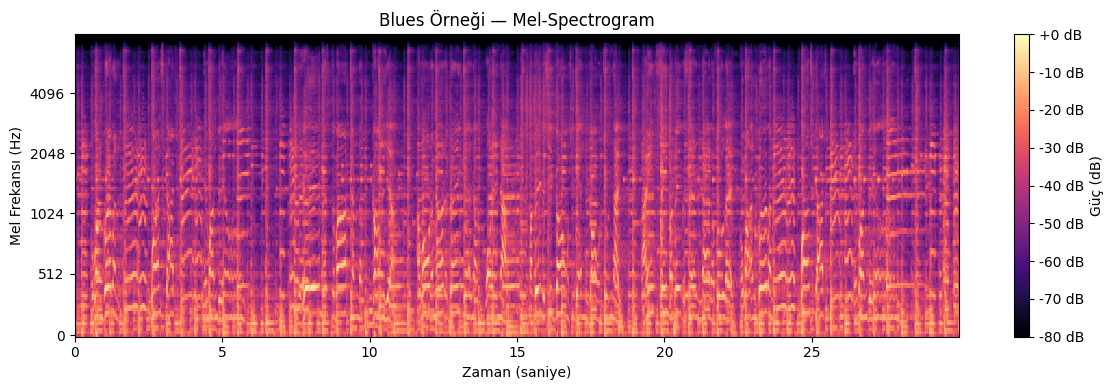

In [ ]:
plt.figure(figsize=(12, 4))
img = librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='mel',
    fmax=8000,
    cmap='magma'
)
plt.colorbar(img, format='%+2.0f dB', label='Güç (dB)')
plt.title('Blues Örneği — Mel-Spectrogram')
plt.xlabel('Zaman (saniye)')
plt.ylabel('Mel Frekansı (Hz)')
plt.tight_layout()
plt.show()

**Gözlem:** Blues örneği için mel-spectrogram beklenen yapıyı gösterdi:
- Alt bölgede (0-512 Hz) sürekli ve parlak bas/kick frekansları
- Orta bölgede (512-2048 Hz) yatay şeritler — vokal ve gitar
- Düzenli dikey çizgiler ritmik vuruşları işaret ediyor (~120 BPM tempo hissi)
- 8000 Hz üstü neredeyse boş (MP3 kaynağından dönüşüm etkisi)

##10 Türün Spectrogram Karşılaştırması

Tüm türlerin ilk dosyasını aynı parametrelerle (n_mels=128, n_fft=2048, hop_length=512) mel-spectrogram'a çevirip 2×5 ızgarada görselleştiriyoruz. Bu, türler arası görsel farkları ortaya koyacak ve raporun "Veri" bölümünde anahtar görsel olacak.

Kaydedildi: /content/drive/MyDrive/gtzan_project/genres_grid.png


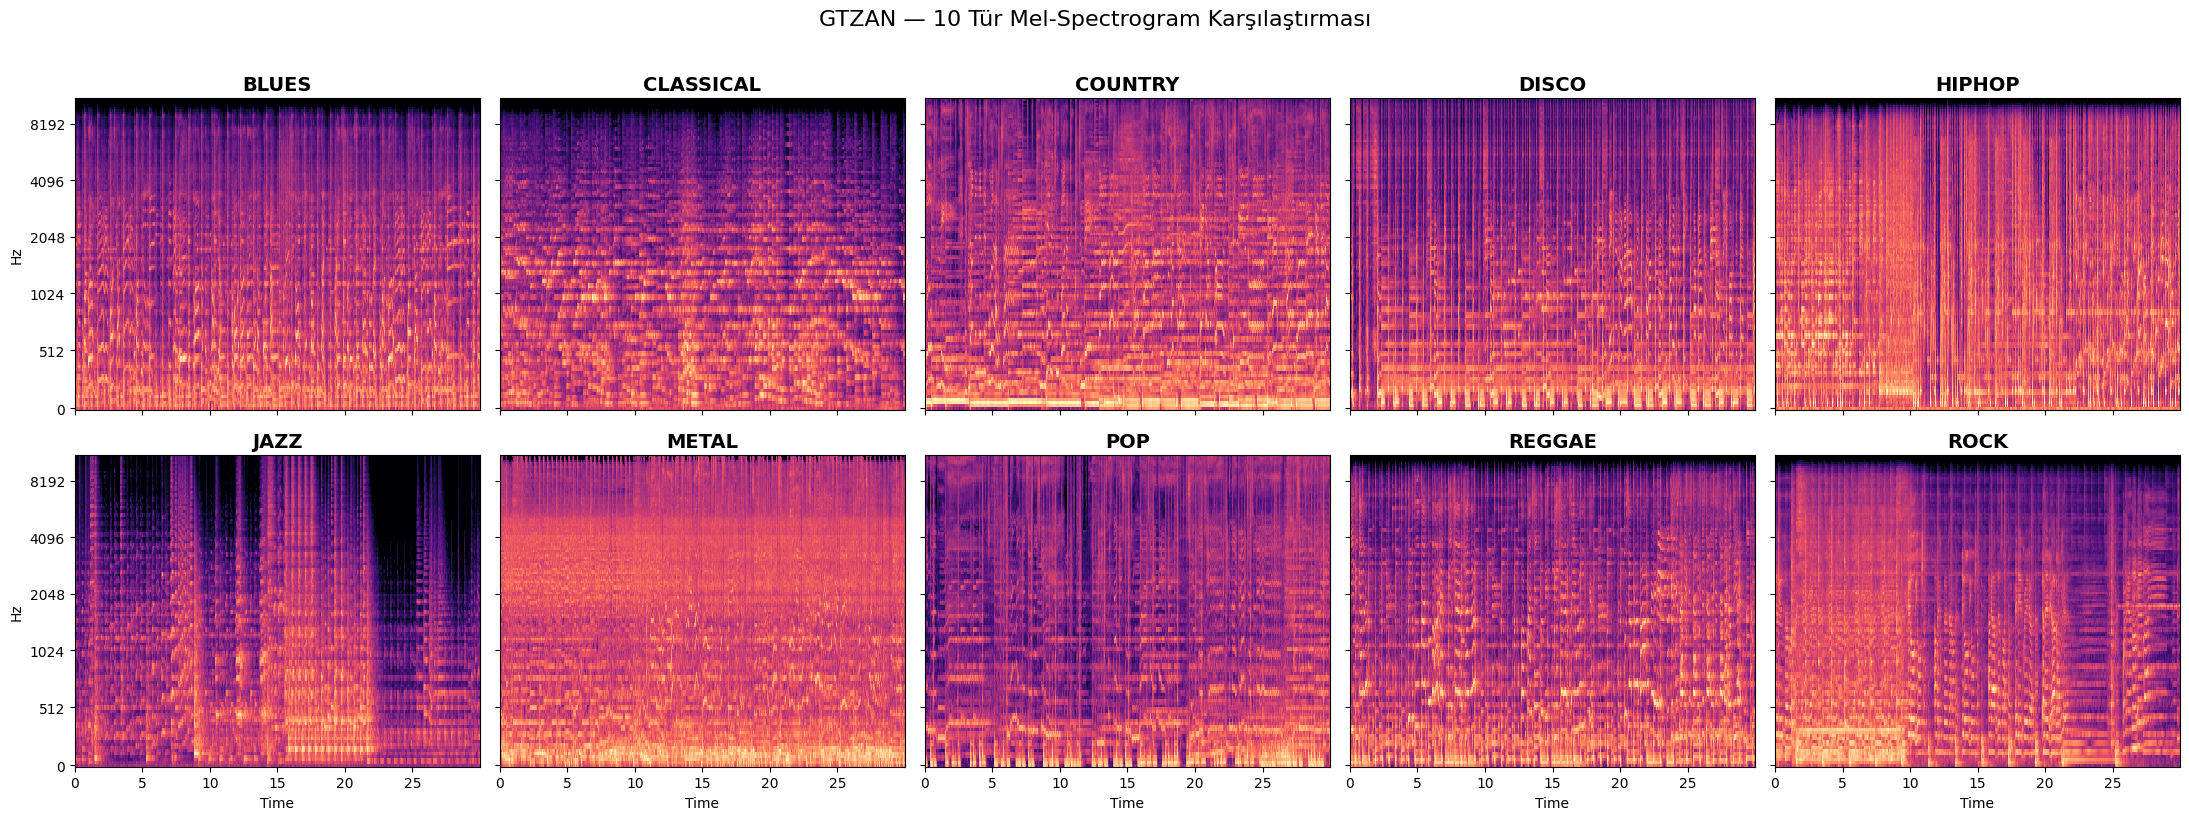

In [ ]:
import os

GENRES_DIR = "/content/gtzan/Data/genres_original"
DRIVE_BASE = "/content/drive/MyDrive/gtzan_project"

genres_all = ["blues", "classical", "country", "disco", "hiphop",
              "jazz", "metal", "pop", "reggae", "rock"]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for ax, g in zip(axes.flat, genres_all):
    file = sorted(os.listdir(f"{GENRES_DIR}/{g}"))[0]
    y, sr = librosa.load(f"{GENRES_DIR}/{g}/{file}", sr=SR, duration=DURATION)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    librosa.display.specshow(
        mel_db, sr=sr, hop_length=HOP_LENGTH,
        ax=ax, x_axis='time', y_axis='mel',
        cmap='magma'
    )
    ax.set_title(g.upper(), fontsize=14, fontweight='bold')
    ax.label_outer()

plt.suptitle("GTZAN — 10 Tür Mel-Spectrogram Karşılaştırması",
             fontsize=16, y=1.02)
plt.tight_layout()

save_path = f"{DRIVE_BASE}/genres_grid.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Kaydedildi: {save_path}")

plt.show()

## Ön İşleme — Partner ile Uyum

Partner'ın notebook'u (`data.ipynb`) ile aynı parametreleri kullandık:
- Sample rate: 22050 Hz
- Mel filtre sayısı: 128
- FFT pencere boyutu: 2048
- Hop length: 512
- Süre: 30 sn (kısa dosyalar sıfırla doldurulur)

Partner bu parametrelerle 999 dosyayı işleyip mel-spectrogram'a çevirdi (1 bozuk dosya atlandı). Sonrasında train setinin istatistikleri kullanılarak z-score normalizasyon uygulandı:
- Train mean: -42.7981 dB
- Train std: 15.5427 dB

Normalize edilmiş veriler `Processed_Data/X_*.npy` olarak kaydedildi, normalizasyon parametreleri `mean_std.npy` dosyasında saklandı. Bu görselleştirme bölümünde ham dB değerleri kullanılmıştır; modele giren veriler normalize edilmiş halleridir.